# Aula Semana 07: Análise de Séries Temporais (Time Series Analysis)
## Fundamentos, Decomposição, Suavização (SMA/EWMA) e Detecção de Anomalias em Negócios e Finanças

---

### 1. Fundamentos de Séries Temporais no Mundo Real

Na maioria das aplicações convencionais de Ciência de Dados (como classificação de clientes ou regressão tabular), as linhas do banco de dados são consideradas independentes e identicamente distribuídas (*i.i.d.*). A ordem em que os dados foram coletados não altera o modelo.

Em **Séries Temporais (Time Series)**, a regra do jogo muda completamente: a **ordem cronológica é a informação mais importante**:

$$Y = \{y_1, y_2, y_3, \dots, y_t, \dots, y_T\}$$

O valor de hoje ($y_t$) tem forte dependência (autocorrelação) com o valor de ontem ($y_{t-1}$). 

> **Exemplos do Cotidiano**:
> * **Finanças & Investimentos**: A cotação de uma ação ou do dólar às 15:00 depende diretamente de onde ela estava negociando às 14:59.
> * **E-commerce & Varejo**: O volume de vendas de uma loja online às 20:00 reflete o pico de acessos do fim do dia e as campanhas em andamento.
> * **Clima & Energia**: A temperatura ambiente ou a demanda de eletricidade da cidade ao meio-dia depende do aquecimento acumulado ao longo da manhã.

---

### 1.1 Os Quatro Componentes Fundamentais de uma Série Temporal

Qualquer sinal temporal complexo pode ser decomposto em quatro blocos construtivos:

```text
┌──────────────────────────────────────────────────────────────────────────────┐
│                    COMPONENTES DE UMA SÉRIE TEMPORAL                         │
│                                                                              │
│   1. Tendência (Tₜ)    : Movimento sustentado de longo prazo (crescimento)   │
│   2. Sazonalidade (Sₜ) : Padrões periódicos que se repetem em ritmo fixo     │
│   3. Ciclo (Cₜ)        : Ondas de longo prazo sem período estritamente fixo  │
│   4. Resíduo / Ruído   : Flutuações aleatórias imprevisíveis (ruído branco)  │
└──────────────────────────────────────────────────────────────────────────────┘
```

1. **Tendência ($T_t$)**: A trajetória estrutural de longo prazo (crescente, decrescente ou lateral).
   * *Exemplo*: Uma startup de tecnologia crescendo e aumentando seu faturamento base ao longo dos meses; ou o aumento gradual da temperatura média ao longo das semanas de verão.
2. **Sazonalidade ($S_t$)**: Oscilações periódicas com frequência fixa (diária, semanal ou anual).
   * *Exemplo*: O trânsito da cidade e as compras online com picos todo fim de tarde/noite (ciclo diário de 24h); o aumento das vendas de supermercado todo sábado.
3. **Ciclo ($C_t$)**: Flutuações de longo prazo ligadas a ciclos econômicos macro (anos de expansão seguidos por recessões), sem data pré-fixada no calendário.
4. **Resíduo ou Ruído Aleatório ($R_t$)**: Variações puramente estocásticas e imprevisíveis causadas pelo acaso (uma notícia de última hora, instabilidade momentânea na rede).

> **Demonstração Visual Imediata**: Veja no código abaixo como esses 4 conceitos se comportam graficamente e como a soma deles dá origem ao sinal real que você observa no dia a dia:

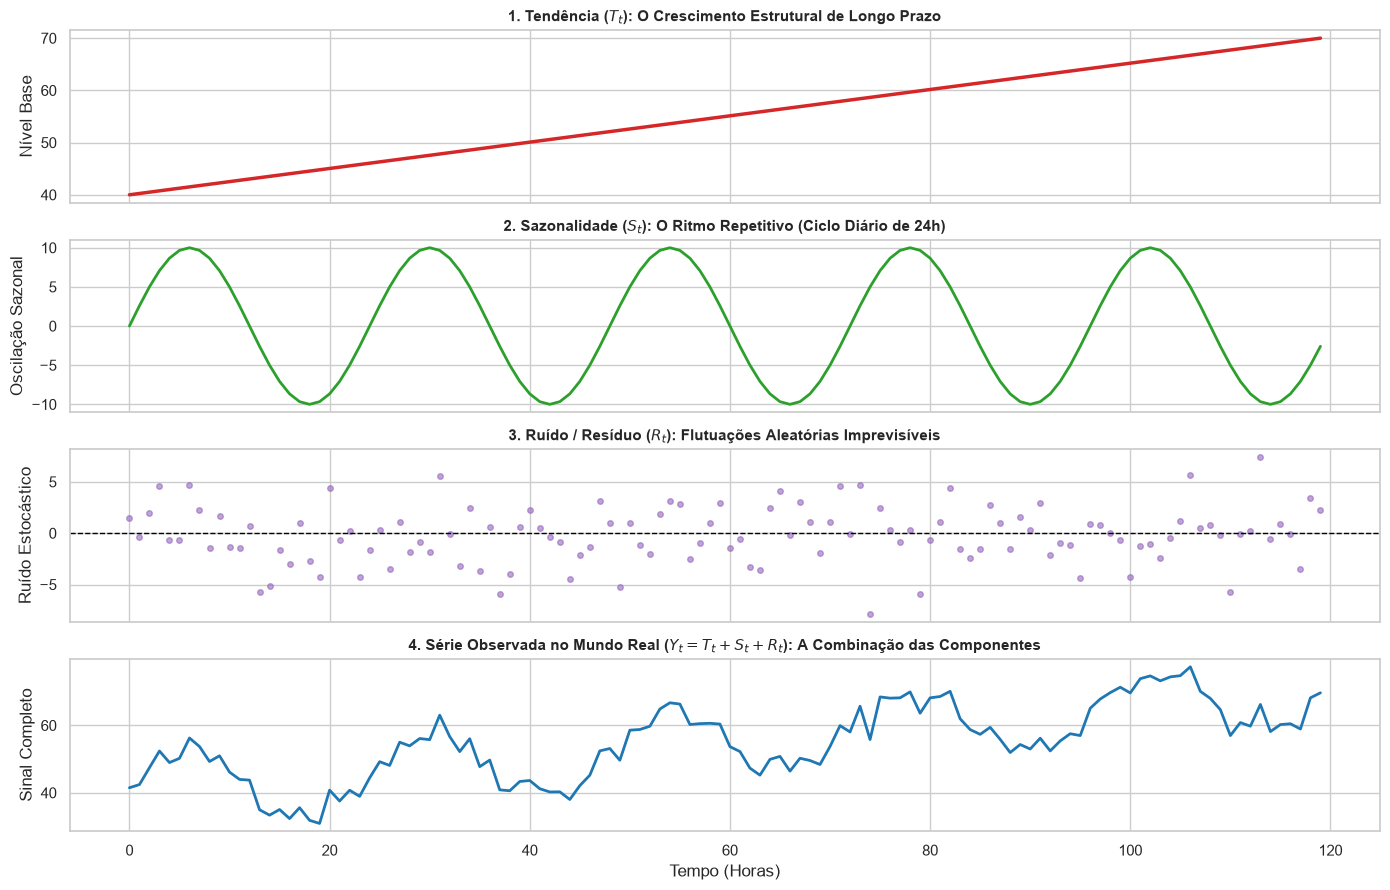

In [1]:
# =============================================================================
# CONCEITO VISUAL: Demonstração Didática dos 4 Componentes de uma Série Temporal
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 10
np.random.seed(42)

# Geramos uma simulação conceitual de 120 horas (5 dias)
t = np.arange(120)

# 1. Tendência (Tt): Crescimento sustentável da empresa ao longo do tempo
tendencia_demo = np.linspace(40, 70, len(t))

# 2. Sazonalidade (St): Ciclo diário de 24 horas (pico à noite e vale na madrugada)
sazonalidade_demo = 10.0 * np.sin(2 * np.pi * t / 24.0)

# 3. Ruído Estocástico (Rt): Flutuações pontuais aleatórias
ruido_demo = np.random.normal(0, 3.0, len(t))

# 4. Série Observada Completa (Yt = Tt + St + Rt): O que enxergamos no mundo real
serie_observada_demo = tendencia_demo + sazonalidade_demo + ruido_demo

# Plotagem em 4 painéis didáticos
fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

axes[0].plot(t, tendencia_demo, color='#d62728', lw=2.5)
axes[0].set_title('1. Tendência ($T_t$): O Crescimento Estrutural de Longo Prazo', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Nível Base')

axes[1].plot(t, sazonalidade_demo, color='#2ca02c', lw=2)
axes[1].set_title('2. Sazonalidade ($S_t$): O Ritmo Repetitivo (Ciclo Diário de 24h)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Oscilação Sazonal')

axes[2].scatter(t, ruido_demo, color='#9467bd', alpha=0.6, s=16)
axes[2].axhline(0, color='black', linestyle='--', lw=1)
axes[2].set_title('3. Ruído / Resíduo ($R_t$): Flutuações Aleatórias Imprevisíveis', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Ruído Estocástico')

axes[3].plot(t, serie_observada_demo, color='#1f77b4', lw=2)
axes[3].set_title('4. Série Observada no Mundo Real ($Y_t = T_t + S_t + R_t$): A Combinação das Componentes', fontweight='bold', fontsize=11)
axes[3].set_ylabel('Sinal Completo')
axes[3].set_xlabel('Tempo (Horas)')

plt.tight_layout()
plt.show()


---

### 1.2 Modelos Clássicos de Decomposição: Aditivo vs. Multiplicativo

Como os componentes se combinam para formar o sinal observado?

1. **Modelo Aditivo**: Assume que os componentes somam-se de forma independente:
   $$Y_t = T_t + S_t + R_t$$
   * **Quando usar**: Quando a amplitude da oscilação sazonal permanece **constante**, não importando o nível da tendência.
   * *Exemplo (Variação de Temperatura Diária)*: No verão ou no inverno, a diferença de temperatura entre o pico do dia (14h) e o momento mais frio da madrugada (04h) oscila sempre em torno de $\pm 8^\circ\text{C}$. Como essa variação não cresce com a média, o modelo aditivo é perfeito.

2. **Modelo Multiplicativo**: Assume que a sazonalidade multiplica a tendência:
   $$Y_t = T_t \times S_t \times R_t$$
   * **Quando usar**: Quando a oscilação sazonal **cresce ou encolhe proporcionalmente** ao tamanho da tendência (efeito visual de "funil").
   * *Exemplo (Black Friday em E-commerce em Crescimento)*: Uma loja virtual dobra suas vendas (+100%) na Black Friday. Quando ela faturava R$ 20 mil/mês, a sazonalidade gerava +R$ 20 mil. Três anos depois, faturando R$ 1 milhão/mês, a mesma Black Friday gera +R$ 1 milhão! A amplitude da sazonalidade explodiu junto com o crescimento da empresa.

---

## 2. Técnicas de Suavização: Média Móvel Simples (SMA) e Exponencial (EWMA)

Séries temporais de preços, vendas diárias e métricas de demanda contêm muito **ruído de alta frequência** (volatilidade momentânea, nervosismo de mercado). Para enxergar o sinal real por trás do ruído, utilizamos técnicas de **suavização (smoothing)**.

---

### 2.1 Média Móvel Simples (SMA - *Simple Moving Average*)

A **SMA** calcula a média aritmética não ponderada das últimas $k$ observações em uma janela móvel:

$$\text{SMA}_t^{(k)} = \frac{1}{k} \sum_{i=0}^{k-1} y_{t-i} = \frac{y_t + y_{t-1} + \dots + y_{t-k+1}}{k}$$

* **Vantagem**: Fácil de entender e calcular.
* **Limitação Crítica: O Atraso (*Lag*)**: A SMA olha para trás e atribui a mesma importância ao dado de hoje e ao dado de $k$ dias atrás.
  * *Exemplo Prático (Ação na Bolsa de Valores)*: Se uma empresa divulga uma descoberta revolucionária e o preço da ação salta hoje de R$ 20 para R$ 50, uma SMA de 30 dias demorará semanas para refletir essa alta. O investidor que depende da SMA só perceberá a mudança tarde demais. E pior: se a ação já estiver estabilizada, a SMA ainda continuará sendo "puxada" pelos dias antigos.

---

### 2.2 Média Móvel Exponencialmente Ponderada (EWMA - *Exponentially Weighted Moving Average*)

A **EWMA** supera a lentidão da SMA ao atribuir **peso exponencialmente maior aos dados mais recentes**, diminuindo a influência do passado de forma suave:

$$\text{EWMA}_t = \alpha \cdot y_t + (1 - \alpha) \cdot \text{EWMA}_{t-1}$$

Onde:
* $y_t$: O valor observado no instante atual (a cotação de agora ou as vendas de hoje).
* $\text{EWMA}_{t-1}$: O valor suavizado acumulado até o instante anterior.
* $\alpha \in (0, 1]$: O **fator de suavização (*smoothing factor*)**:
  * **$\alpha$ alto (ex: $0.40$ a $0.80$) — O Perfil Reativo ("Day Trader")**: Dá enorme peso ao que acabou de acontecer. Reage prontamente a viradas de mercado ou quebras de padrão, mas deixa passar mais oscilações.
  * **$\alpha$ baixo (ex: $0.05$ a $0.15$) — O Perfil Estável ("Investidor de Longo Prazo")**: Dá muito mais peso ao histórico consolidado. Gera uma curva suave e elegante, filtrando o nervosismo do dia a dia.

---

## 3. Aplicação Prática: Análise Detalhada no Dataset de E-commerce

A partir de agora, aplicaremos todos esses conceitos de forma aprofundada importando o dataset real de faturamento e vendas horárias: `Dataset_Ecommerce_Faturamento_Horario.csv`.

In [2]:
# =============================================================================
# ETAPA 1: Importação do Dataset CSV e Estruturação do Índice Temporal
# Dataset: Faturamento Horário e Métricas de E-commerce
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import os
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

# Caminho do arquivo CSV na pasta materiais
candidatos_caminho = [
    "../materiais/Dataset_Ecommerce_Faturamento_Horario.csv",
    "materiais/Dataset_Ecommerce_Faturamento_Horario.csv",
    r"c:\projetos\Material\Ciencia de Dados\materiais\Dataset_Ecommerce_Faturamento_Horario.csv"
]

csv_path = None
for p in candidatos_caminho:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Arquivo 'Dataset_Ecommerce_Faturamento_Horario.csv' não encontrado na pasta materiais!")

# Importação do dataset a partir do arquivo CSV
df_raw = pd.read_csv(csv_path)
print(f"✓ Dataset importado com sucesso de: '{csv_path}'")
print(f"✓ Dimensões do dataset: {df_raw.shape[0]} registros horários e {df_raw.shape[1]} colunas.")

# Conversão da coluna de data/hora para datetime e definição como índice temporal
df_raw['data_hora'] = pd.to_datetime(df_raw['data_hora'])
df_ts = df_raw.set_index('data_hora')

# Exibe a prévia dos dados carregados
display(df_ts.head(8))

# Selecionamos a série temporal principal: Faturamento Horário (em milhares de R$)
serie = df_ts['faturamento_milhares_reais'].copy()

# Tratamento de qualidade: interpolação temporal e remoção de percentis extremos
serie = serie.interpolate(method='time').bfill()
serie_clean = serie[(serie > serie.quantile(0.01)) & (serie < serie.quantile(0.99))]

print(f"✓ Série temporal pronta para análise: {len(serie_clean)} observações horárias limpas.")


✓ Dataset importado com sucesso de: '../materiais/Dataset_Ecommerce_Faturamento_Horario.csv'
✓ Dimensões do dataset: 1000 registros horários e 5 colunas.


,faturamento_milhares_reais,num_pedidos,ticket_medio_reais,visitas_site
data_hora,,,,
2026-01-01 00:00:00,51.74,254,203.70,4437
2026-01-01 01:00:00,51.62,246,209.84,4399
2026-01-01 02:00:00,56.34,254,221.81,4414
2026-01-01 03:00:00,61.09,265,230.53,4708
2026-01-01 04:00:00,56.25,264,213.07,4373
2026-01-01 05:00:00,57.08,263,217.03,4777
2026-01-01 06:00:00,63.74,300,212.47,5400
2026-01-01 07:00:00,60.66,282,215.11,4913


✓ Série temporal pronta para análise: 980 observações horárias limpas.


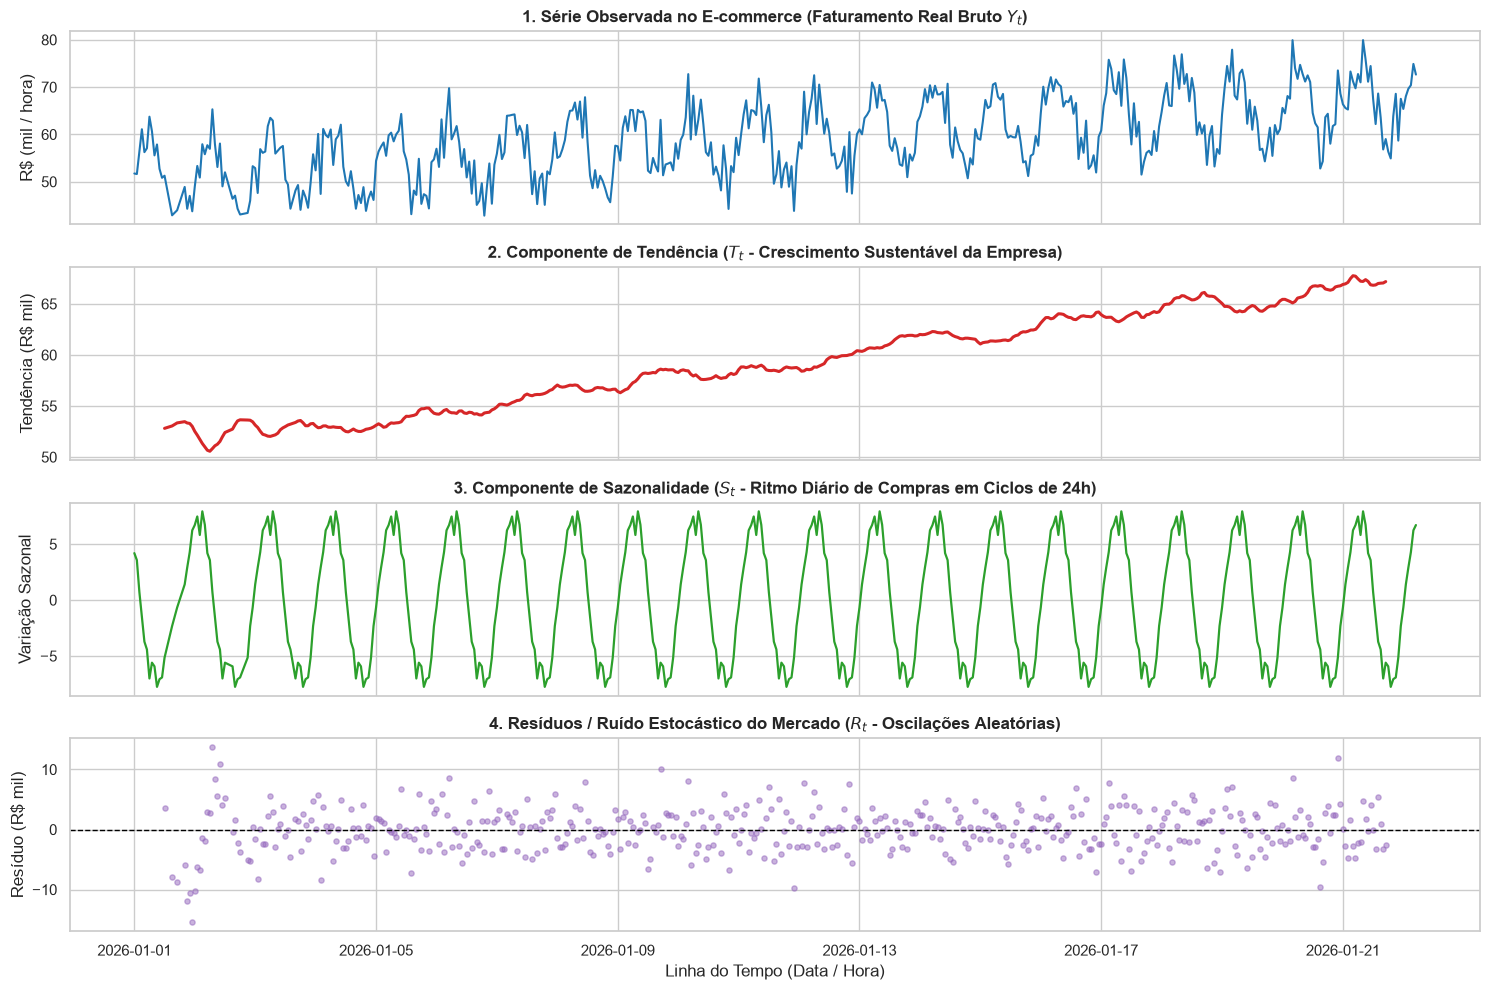

In [3]:
# =============================================================================
# ETAPA 2: Decomposição Estatística Completa (Tendência, Sazonalidade e Ruído)
# =============================================================================
sub_serie = serie_clean.iloc[:500].copy()

try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    # Decomposição Aditiva com período sazonal de 24 horas (ciclo diário de consumo)
    decomposicao = seasonal_decompose(sub_serie, model='additive', period=24)
    trend_vals = decomposicao.trend
    seasonal_vals = decomposicao.seasonal
    resid_vals = decomposicao.resid
except Exception as e:
    print(f"Fallback para decomposição via médias móveis com Pandas: {e}")
    trend_vals = sub_serie.rolling(window=24, center=True).mean()
    detrended = sub_serie - trend_vals
    seasonal_vals = detrended.groupby(detrended.index.hour).transform('mean')
    resid_vals = sub_serie - trend_vals - seasonal_vals

# Visualização didática alinhada em 4 painéis
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

# 1. Série Observada Real (Yt)
axes[0].plot(sub_serie.index, sub_serie.values, color='#1f77b4', lw=1.5)
axes[0].set_title('1. Série Observada no E-commerce (Faturamento Real Bruto $Y_t$)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R$ (mil / hora)')

# 2. Tendência (Tt)
axes[1].plot(trend_vals.index, trend_vals.values, color='#d62728', lw=2.2)
axes[1].set_title('2. Componente de Tendência ($T_t$ - Crescimento Sustentável da Empresa)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tendência (R$ mil)')

# 3. Sazonalidade (St)
axes[2].plot(seasonal_vals.index, seasonal_vals.values, color='#2ca02c', lw=1.6)
axes[2].set_title('3. Componente de Sazonalidade ($S_t$ - Ritmo Diário de Compras em Ciclos de 24h)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Variação Sazonal')

# 4. Resíduos / Ruído (Rt)
axes[3].scatter(resid_vals.index, resid_vals.values, color='#9467bd', alpha=0.5, s=14)
axes[3].axhline(0, color='black', linestyle='--', lw=1)
axes[3].set_title('4. Resíduos / Ruído Estocástico do Mercado ($R_t$ - Oscilações Aleatórias)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Resíduo (R$ mil)')
axes[3].set_xlabel('Linha do Tempo (Data / Hora)')

plt.tight_layout()
plt.show()


---
### Análise e Interpretação Didática: O que os 4 Gráficos Revelam?

A decomposição temporal separa a complexidade das vendas brutas em quatro visões estratégicas essenciais para o gestor de negócios e analista de dados:

1. **Série Observada (Faturamento Bruto $Y_t$)**:
   * **O que vemos**: O dinheiro que entra a cada hora, com subidas e descidas frequentes.
   * **Desafio Prático**: Analisar apenas o número bruto gera ansiedade na equipe: se as vendas caem às 03h da manhã, o time de marketing pode achar que o site caiu ou que a campanha falhou.

2. **Componente de Tendência ($T_t$)**:
   * **O que vemos**: Uma linha límpida e ascendente subindo de **R$ 50 mil para mais de R$ 80 mil por hora**.
   * **Significado nos Negócios**: Representa a **saúde estrutural do negócio** (aquisição orgânica de novos clientes, expansão de marca). É esta curva que o CEO e os investidores acompanham para saber se a empresa está crescendo de verdade no longo prazo.

3. **Componente de Sazonalidade ($S_t$)**:
   * **O que vemos**: Uma onda senoidal regular com amplitude de **$\pm 8$ mil reais**, completando exatamente um ciclo a cada 24 horas.
   * **Significado nos Negócios**: Reflete o **hábito natural dos consumidores**. Ao final da tarde e início da noite, as compras aumentam em até R$ 8 mil em relação à média; de madrugada, reduzem na mesma proporção. Identificar a sazonalidade evita conclusões erradas: a equipe aprende que a queda da madrugada é normal e não uma crise.

4. **Resíduos / Ruído Aleatório ($R_t$)**:
   * **O que vemos**: Pontos aleatoriamente dispersos em torno de zero, oscilando entre $-7$ e $+7$ mil reais.
   * **Significado nos Negócios**: Pequenas variações imprevisíveis (um cliente corporativo que fez um pedido grande pontual, instabilidade temporária na internet). Como os pontos estão espalhados como "ruído branco" em torno de zero, temos a comprovação estatística de que o modelo explicou com perfeição a tendência e os horários de compra.

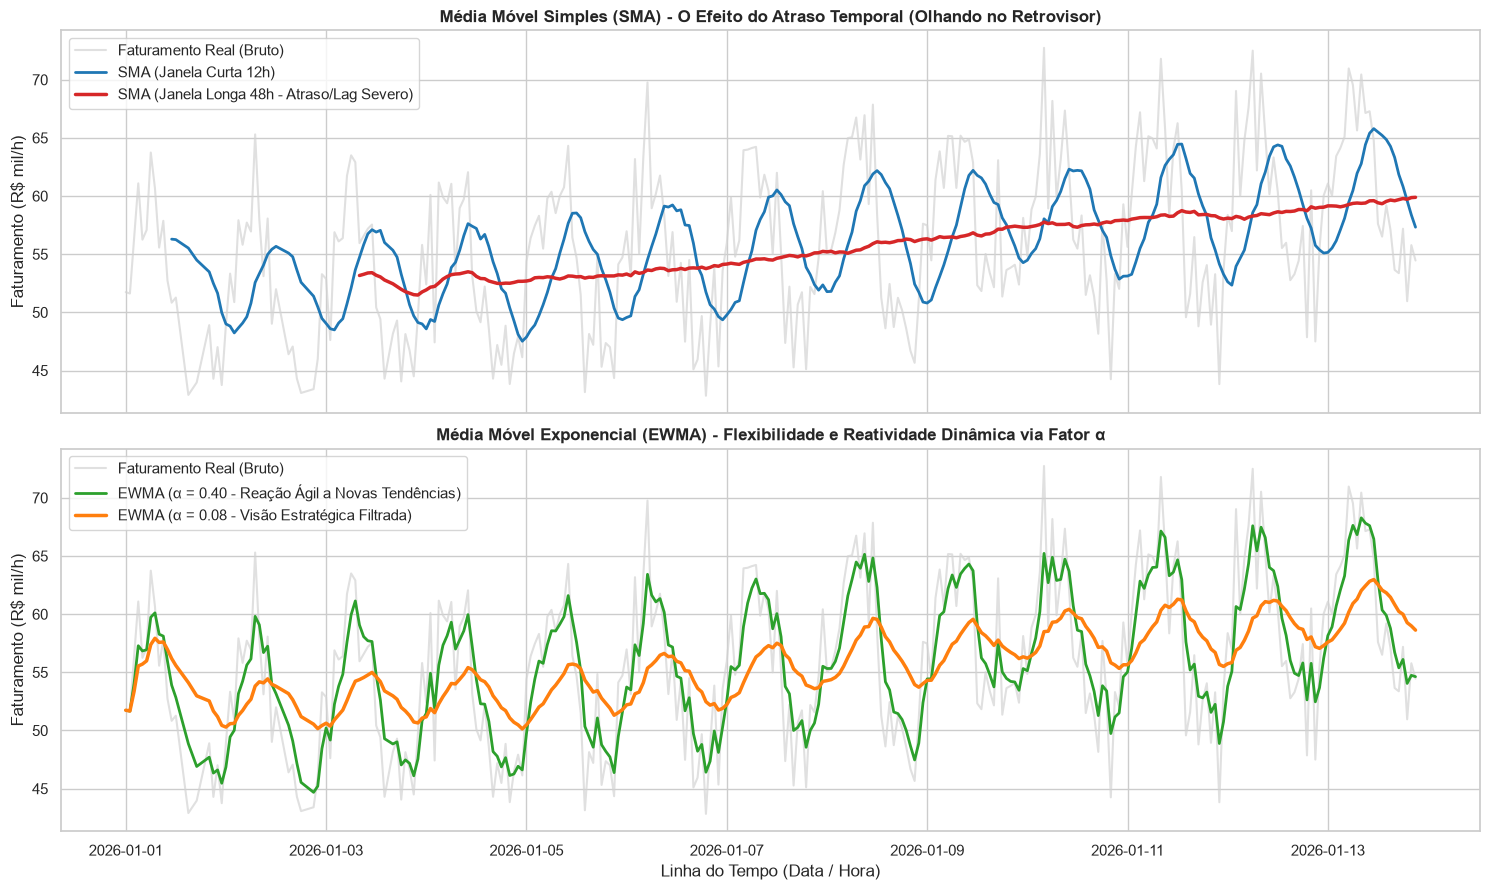

In [4]:
# =============================================================================
# ETAPA 3: Comparação de Técnicas de Suavização: SMA vs. EWMA
# =============================================================================
sub_serie = serie_clean.iloc[:300].copy()

# 1. Médias Móveis Simples (SMA)
sma_12h = sub_serie.rolling(window=12).mean()
sma_48h = sub_serie.rolling(window=48).mean()

# 2. Médias Móveis Exponenciais (EWMA)
ewma_rapida = sub_serie.ewm(alpha=0.40).mean()  # Reação ágil (alpha = 0.40)
ewma_suave = sub_serie.ewm(alpha=0.08).mean()   # Filtro estável de ruído (alpha = 0.08)

# Visualização Comparativa
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# Painel 1: Média Móvel Simples (SMA)
axes[0].plot(sub_serie.index, sub_serie.values, color='lightgray', alpha=0.7, label='Faturamento Real (Bruto)')
axes[0].plot(sma_12h.index, sma_12h.values, color='#1f77b4', lw=2, label='SMA (Janela Curta 12h)')
axes[0].plot(sma_48h.index, sma_48h.values, color='#d62728', lw=2.5, label='SMA (Janela Longa 48h - Atraso/Lag Severo)')
axes[0].set_title('Média Móvel Simples (SMA) - O Efeito do Atraso Temporal (Olhando no Retrovisor)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Faturamento (R$ mil/h)')
axes[0].legend(loc='upper left')

# Painel 2: Média Móvel Exponencial (EWMA)
axes[1].plot(sub_serie.index, sub_serie.values, color='lightgray', alpha=0.7, label='Faturamento Real (Bruto)')
axes[1].plot(ewma_rapida.index, ewma_rapida.values, color='#2ca02c', lw=2, label='EWMA (α = 0.40 - Reação Ágil a Novas Tendências)')
axes[1].plot(ewma_suave.index, ewma_suave.values, color='#ff7f0e', lw=2.5, label='EWMA (α = 0.08 - Visão Estratégica Filtrada)')
axes[1].set_title('Média Móvel Exponencial (EWMA) - Flexibilidade e Reatividade Dinâmica via Fator α', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Faturamento (R$ mil/h)')
axes[1].set_xlabel('Linha do Tempo (Data / Hora)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


---
### Análise e Interpretação Didática: O Duelo SMA vs. EWMA no Mundo Real

Ao comparar as duas técnicas nos gráficos acima, observamos decisões estratégicas cruciais para quem monitora indicadores em tempo real:

1. **O Problema da Média Móvel Simples (SMA)**:
   * **Janela Curta (12h)**: Suaviza apenas ruídos muito rápidos, mas ainda oscila excessivamente.
   * **Janela Longa (48h)**: Produz uma curva bonita e lisa, **mas com um atraso (*lag*) perigoso**. Quando as vendas da empresa já subiram há dois dias, a linha vermelha da SMA de 48h ainda está baixa, olhando para o passado. Em finanças ou gestão de estoque, esse atraso levaria a decisões erradas de compra e falta de produtos para atender a demanda.

2. **A Grande Vantagem da Média Móvel Exponencial (EWMA)**:
   * **$\alpha = 0.40$ (Reatividade Rápida)**: Acompanha novas tendências quase em tempo real, sem o atraso da SMA e sem a trepidação do ruído estocástico. É ideal para equipes de marketing detectarem rapidamente o sucesso de uma nova campanha ou promoção relâmpago.
   * **$\alpha = 0.08$ (Filtro Estável)**: Remove o ruído diário preservando o movimento estrutural dos dados, sem arrastar dados velhos por semanas como a SMA.
   * **Conclusão**: A EWMA é amplamente preferida no mercado financeiro e no varejo digital porque permite calibrar exatamente o equilíbrio entre velocidade de reação e filtragem de ruído.

  MONITORAMENTO ESTATÍSTICO DE DEMANDA / FATURAMENTO (CARTA EWMA)
• Faturamento Médio Histórico (CL)  : R$ 57.63 mil / h
• Limite Superior de Controle (LSC) : R$ 64.96 mil / h (+3σ)
• Limite Inferior de Controle (LIC) : R$ 50.30 mil / h (-3σ)
• Alertas de Anomalia Detectados     : 76 eventos fora de controle


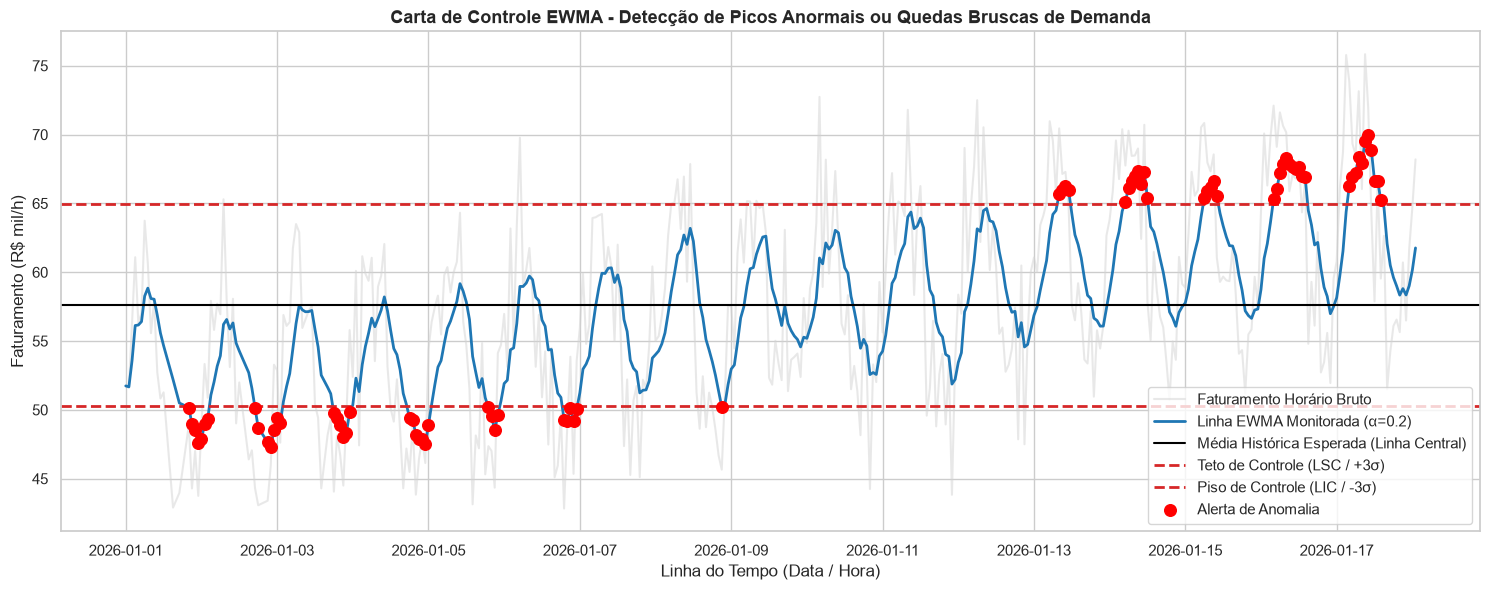

In [5]:
# =============================================================================
# ETAPA 4: Carta de Controle EWMA e Gestão de Anomalias de Demanda
# =============================================================================
sub_serie = serie_clean.iloc[:400].copy()

# Parâmetros de calibração da Carta EWMA
alpha_controle = 0.20
ewma_serie = sub_serie.ewm(alpha=alpha_controle).mean()
media_historica = sub_serie.mean()
desvio_historico = sub_serie.std()

# Limites Estatísticos (3 Sigmas EWMA)
# Fórmula da dispersão reduzida: sigma_ewma = sigma * sqrt(alpha / (2 - alpha))
sigma_ewma = desvio_historico * np.sqrt(alpha_controle / (2.0 - alpha_controle))
limite_superior = media_historica + (3.0 * sigma_ewma)
limite_inferior = media_historica - (3.0 * sigma_ewma)

# Identificação de anomalias fora da faixa esperada
anomalias = ewma_serie[(ewma_serie > limite_superior) | (ewma_serie < limite_inferior)]

print("=" * 70)
print("  MONITORAMENTO ESTATÍSTICO DE DEMANDA / FATURAMENTO (CARTA EWMA)")
print("=" * 70)
print(f"• Faturamento Médio Histórico (CL)  : R$ {media_historica:.2f} mil / h")
print(f"• Limite Superior de Controle (LSC) : R$ {limite_superior:.2f} mil / h (+3σ)")
print(f"• Limite Inferior de Controle (LIC) : R$ {limite_inferior:.2f} mil / h (-3σ)")
print(f"• Alertas de Anomalia Detectados     : {len(anomalias)} eventos fora de controle")
print("=" * 70)

# Plotagem da Carta de Controle
plt.figure(figsize=(15, 6))
plt.plot(sub_serie.index, sub_serie.values, color='lightgray', alpha=0.5, label='Faturamento Horário Bruto')
plt.plot(ewma_serie.index, ewma_serie.values, color='#1f77b4', lw=2, label=f'Linha EWMA Monitorada (α={alpha_controle})')
plt.axhline(media_historica, color='black', linestyle='-', lw=1.5, label='Média Histórica Esperada (Linha Central)')
plt.axhline(limite_superior, color='#d62728', linestyle='--', lw=2, label='Teto de Controle (LSC / +3σ)')
plt.axhline(limite_inferior, color='#d62728', linestyle='--', lw=2, label='Piso de Controle (LIC / -3σ)')

if len(anomalias) > 0:
    plt.scatter(anomalias.index, anomalias.values, color='red', s=70, zorder=5, label='Alerta de Anomalia')

plt.title('Carta de Controle EWMA - Detecção de Picos Anormais ou Quedas Bruscas de Demanda', fontsize=13, fontweight='bold')
plt.ylabel('Faturamento (R$ mil/h)')
plt.xlabel('Linha do Tempo (Data / Hora)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


---
### Análise e Interpretação Didática: Cartas EWMA e Gestão de Anomalias

A Carta de Controle EWMA funciona de maneira análoga às **Bandas de Bollinger** no mercado financeiro e aos sistemas de inteligência de negócios:

1. **Estrutura dos Limites Estatísticos**:
   * **Linha Central (CL)**: O faturamento médio histórico das primeiras 400 horas do negócio (**R$ 57.63 mil / hora**).
   * **Limites de Controle ($\pm 3\sigma_{\text{ewma}}$)**: Definem o corredor esperado para o patamar inicial:
     * **Piso Inferior (LIC)**: **R$ 50.30 mil / hora** ($-3\sigma$).
     * **Teto Superior (LSC)**: **R$ 64.96 mil / hora** ($+3\sigma$).
   * **A Mágica da EWMA**: Pela fórmula $\sigma_{\text{ewma}} = \sigma \sqrt{\frac{\alpha}{2 - \alpha}}$, com $\alpha = 0.20$, o desvio é reduzido para aproximadamente **um terço ($33.3\%$)** da dispersão bruta. Isso torna os limites muito mais sensíveis e precisos do que métodos estáticos tradicionais.

2. **Interpretação Prática do Gráfico e dos 76 Alertas**:
   * **Detecção Precoce de Mudança de Patamar**: Observe que, conforme a empresa cresce (tendência sustentada de alta), a curva azul cruza o teto de **R$ 64.96 mil / hora** e acende **76 alertas vermelhos** de eventos acima do limite de controle.
   * **Aplicação em Negócios e Finanças**:
     * **Em Vendas/E-commerce**: Esses alertas sinalizam que a empresa superou a sua capacidade histórica anterior, exigindo expansão imediata de infraestrutura em nuvem, contratação de suporte e ampliação de estoque.
     * **Em Segurança/Fraude**: Se esse salto ocorresse em questão de poucos minutos, o alarme identificaria um ataque de compras fraudulentas com cartões roubados ou um ataque de tráfego DDoS.

---
## 4. Exercícios de Fixação e Estudos Dirigidos

### Exercício 1: Identificação de Componentes em Plataformas de Streaming
Uma plataforma de filmes e séries analisou o número diário de horas assistidas ao longo de 12 meses:
* Observou-se um crescimento de 5% a cada mês no total de horas assistidas.
* Todo sábado e domingo, o consumo é 40% maior do que nos dias úteis.
1. Qual padrão corresponde à **Tendência** e qual corresponde à **Sazonalidade**?
2. Por que, nesse caso de crescimento percentual constante, o **Modelo Multiplicativo** é mais adequado do que o Aditivo?

---

### Exercício 2: Escolha do Fator de Suavização $\alpha$ na EWMA
Um cientista de dados foi contratado por um banco digital para criar dois sistemas de monitoramento:
* **Sistema A**: Alerta instantâneo para identificar ataques cibernéticos ou transações suspeitas no cartão de crédito em tempo real.
* **Sistema B**: Estimativa de receita trimestral consolidada para apresentação ao conselho de administração.
1. Para o **Sistema A**, deve-se usar um $\alpha$ alto (ex: $0.70$) ou baixo (ex: $0.05$)? Justifique.
2. E para o **Sistema B**? Qual a principal vantagem da EWMA sobre a Média Móvel Simples (SMA) nesse planejamento?

---

### Exercício 3: Análise Prática de Finanças e Vendas
Considere uma série temporal diária de cotação de um fundo imobiliário ou faturamento de varejo:
1. Se utilizarmos uma SMA com janela de $k = 60$ dias, o que acontece com a curva quando ocorre uma queda brusca de mercado?
2. Como uma EWMA com $\alpha = 0.25$ responderia a essa mesma queda brusca?

---

### Exercício 4: Diagnóstico de Resíduos e Ruído Branco
Após decompor uma série temporal de demanda de energia elétrica de uma cidade, aplicou-se um teste estatístico sobre a componente de **Resíduos ($R_t$)**, constatando-se média zero, variância constante e ausência de autocorrelação (ruído branco).
1. O que esse diagnóstico indica sobre a qualidade da decomposição e a precisão na separação de tendência e sazonalidade?